# 16 - Visualise Projection Results

## Research purpose

Compare projected workload-shifting potential across the six IEA demand endpoints and examine the effects of workload assumptions and regional allocation patterns. These scenarios uniformly scale the validated current-plus-future results while retaining their existing spatial distribution.


## Imports

Load the libraries used to read the projection summaries and draw the comparison figures.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

## Project paths

Locate the project root and define the paths for the combined projection summary, directed-region summary and saved figures.


In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "notebooks").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    raise RuntimeError("Launch Jupyter from the folder containing data/ and notebooks/, or from its notebooks/ directory.")

DATA_FINAL = PROJECT_ROOT / "data" / "final"
SUMMARY_PATH = DATA_FINAL / "candidate_hours_projected_flexibility_summary.csv"
REGION_PATH = DATA_FINAL / "candidate_hours_projected_flexibility_region_pair_summary.csv"
VIS_ROOT = PROJECT_ROOT / "visualizations" / "projections"
METHOD_OUTPUT_DIRS = {"greedy": VIS_ROOT / "greedy", "optimised_lp": VIS_ROOT / "optimised"}

## Comparison settings

Define the demand endpoints, workload assumptions, candidate-hour settings and shared plotting style. Use Optimised LP as the primary technical-potential method and Greedy as the comparison, keeping the scenarios and shifting modes as separate alternatives.


In [3]:
CANDIDATE_HOURS = [6, 9]
METHOD_LABELS = {"greedy": "Greedy", "optimised_lp": "Optimised LP"}
MODE_ORDER = ["daily_spatiotemporal", "same_hour_geographic"]
MODE_LABELS = {"daily_spatiotemporal": "Daily spatio-temporal", "same_hour_geographic": "Same-hour geographic"}
MODE_COLOURS = {"daily_spatiotemporal": "#2c7fb8", "same_hour_geographic": "#f28e2b"}
SCENARIO_ORDER = ["conservative", "moderate", "accelerated"]
SCENARIO_LABELS = {"conservative": "Conservative", "moderate": "Moderate", "accelerated": "Accelerated"}
SCENARIO_COLOURS = {"conservative": "#59a14f", "moderate": "#4e79a7", "accelerated": "#e15759"}
TARGET_YEARS = [2030, 2035]
ENDPOINT_LABELS = [f"{SCENARIO_LABELS[scenario]} {year}" for year in TARGET_YEARS for scenario in SCENARIO_ORDER]
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

## Load projections

Read the projection summary and directed-region summary used in the figures below.


In [4]:
summary = pd.read_csv(SUMMARY_PATH)
region = pd.read_csv(REGION_PATH)

## Figure saving and shared scales

Define functions to calculate positive axis limits and display, save and close each figure. Shared limits allow comparisons across both methods and candidate-hour settings.


In [5]:
# Leave useful plotting space when every value is zero or undefined.
def positive_limit(values, factor=1.0):
    maximum = pd.Series(values).max()
    return float(maximum) * factor if pd.notna(maximum) and maximum > 0 else 1.0

# Display, save and close only the figure supplied by the current cell.
def save_figure(fig, directory, name):
    directory.mkdir(parents=True, exist_ok=True)
    if fig.get_layout_engine() is None:
        fig.tight_layout()
    display(fig)
    fig.savefig(directory / f"{name}.png", bbox_inches="tight")
    plt.close(fig)

## 1 - Reference projections

Select 85% utilisation and 25% flexibility within both candidate-hour settings and arrange the six demand endpoints in a consistent order. Inspect the median annual shifted energy across weather runs for the reference cases.


In [6]:
reference_summary = summary.loc[
    summary["utilisation_scenario_id"].eq("util_85") & summary["flexibility_scenario_id"].eq("flex_25")
].copy()
reference_summary["scenario_year"] = pd.Categorical(
    reference_summary["demand_scenario_id"].map(SCENARIO_LABELS) + " " + reference_summary["target_year"].astype(str),
    categories=ENDPOINT_LABELS, ordered=True,
)

reference_summary = reference_summary.sort_values(["candidate_hours", "allocation_method", "scenario_year", "shift_mode"])

display(reference_summary[["candidate_hours", "allocation_method", "scenario_year", "shift_mode", "shifted_gwh_median"]].head(12))

,candidate_hours,allocation_method,scenario_year,shift_mode,shifted_gwh_median
176,6,greedy,Conservative 2030,daily_spatiotemporal,5774.600865
177,6,greedy,Conservative 2030,same_hour_geographic,3410.613843
320,6,greedy,Moderate 2030,daily_spatiotemporal,7916.791509
321,6,greedy,Moderate 2030,same_hour_geographic,4675.841559
32,6,greedy,Accelerated 2030,daily_spatiotemporal,10058.982153
33,6,greedy,Accelerated 2030,same_hour_geographic,5941.069275
248,6,greedy,Conservative 2035,daily_spatiotemporal,5960.878313
249,6,greedy,Conservative 2035,same_hour_geographic,3520.633644
392,6,greedy,Moderate 2035,daily_spatiotemporal,9593.288534
393,6,greedy,Moderate 2035,same_hour_geographic,5666.019771


### Prepare the endpoint comparison

Calculate a shared upper axis limit from the maximum annual weather results across both allocation methods and candidate-hour settings. Define a plotting function that compares median annual energy for the two shifting modes at each demand endpoint.


In [7]:
shifted_energy_upper = positive_limit(reference_summary["shifted_gwh_max_weather_year"], 1.10)

def plot_shifted_energy(data, *, hours, labels, method_label, modes, mode_labels, colours, upper):
    """Compare the two shift modes at each endpoint in matched candidate-hour panels."""
    fig, axes = plt.subplots(1, len(hours), figsize=(19, 6.2), sharey=True, layout="constrained")
    x, width = np.arange(len(labels)), 0.36
    for ax, candidate_hours in zip(np.atleast_1d(axes), hours):
        panel = data.loc[data["candidate_hours"].eq(candidate_hours)]
        for offset, mode in zip([-width / 2, width / 2], modes):
            values = panel.loc[panel["shift_mode"].eq(mode)].set_index("scenario_year").reindex(labels)["shifted_gwh_median"]
            ax.bar(x + offset, values, width, label=mode_labels[mode], color=colours[mode])
        ax.set_xticks(x, [label.replace(" ", "\n") for label in labels], rotation=0, ha="center")
        ax.set_ylim(0, upper)
        ax.set_title(f"{candidate_hours}h candidate setting")
    axes[0].set_ylabel("Annual shifted energy (GWh)")
    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="outside lower center", ncol=2, frameon=False, borderpad=1.2)
    fig.suptitle(f"Projected workload-shifting potential - {method_label}\n", fontsize=16)
    return fig

### 1a - Shifted energy by endpoint: Greedy

Plot Greedy's median annual shifted energy at all six demand endpoints for the reference workload assumptions. Daily and same-hour shifting appear side by side, with a common scale for the six-hour and nine-hour panels.


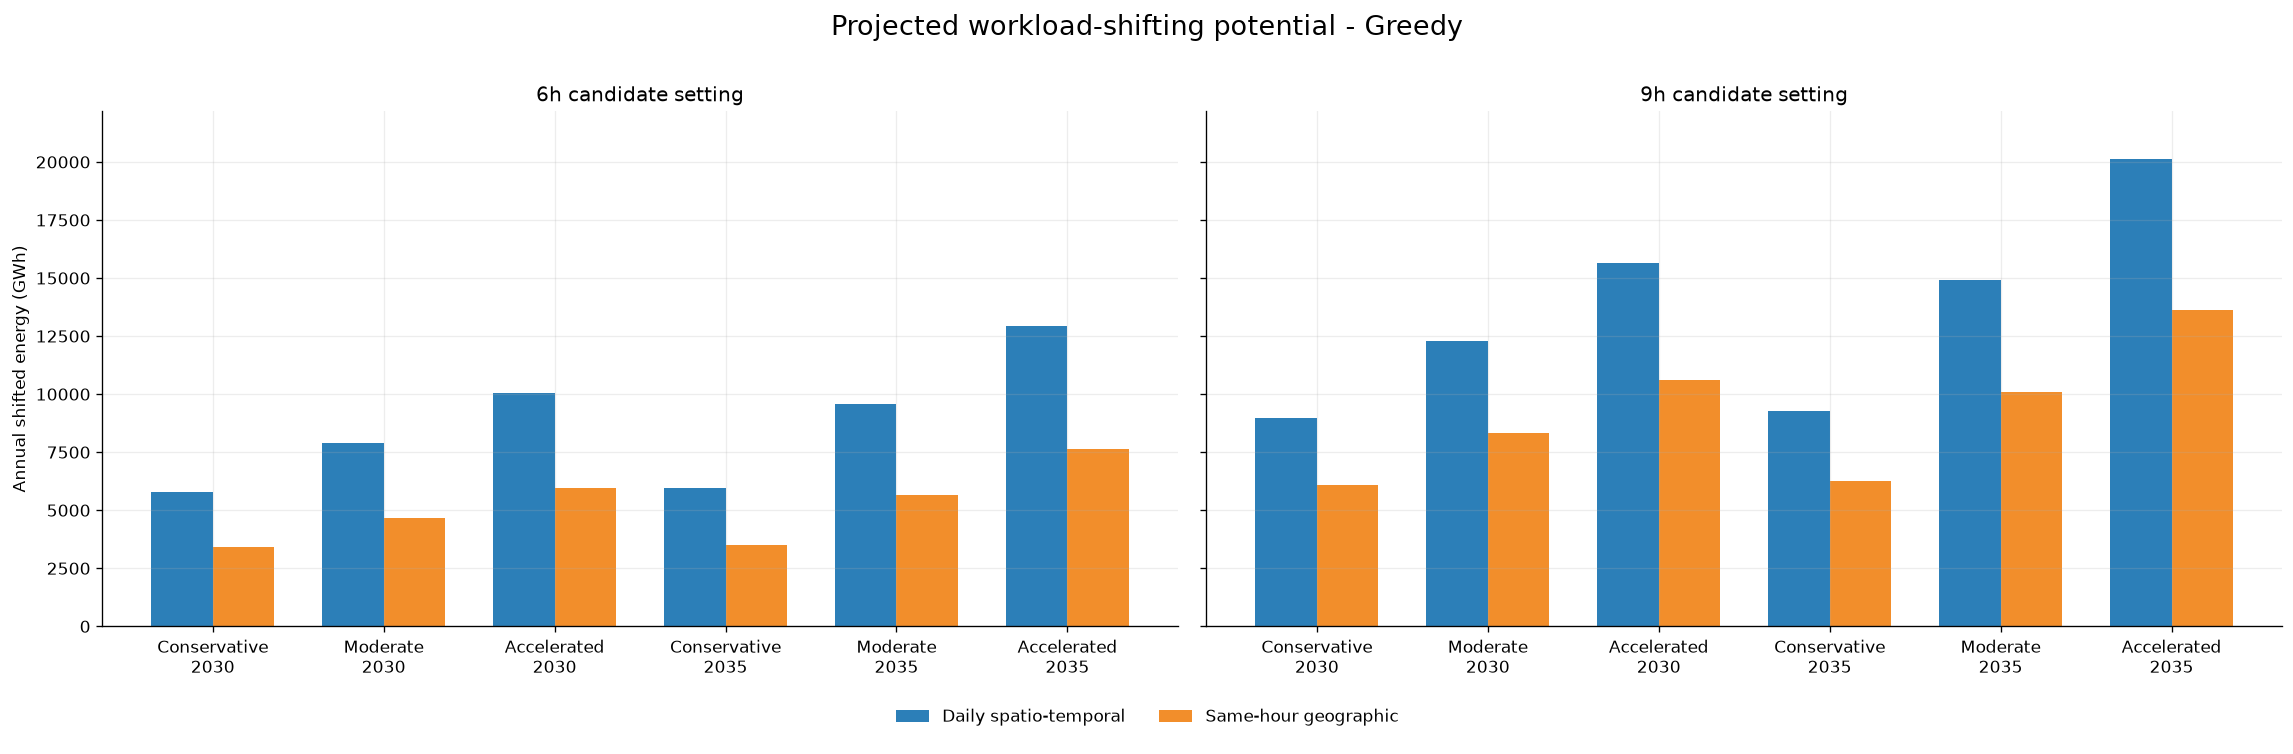

In [8]:
plot_data = reference_summary.loc[reference_summary["allocation_method"].eq("greedy")].copy()

fig = plot_shifted_energy(
    plot_data, hours=CANDIDATE_HOURS, labels=ENDPOINT_LABELS, method_label=METHOD_LABELS["greedy"],
    modes=MODE_ORDER, mode_labels=MODE_LABELS, colours=MODE_COLOURS, upper=shifted_energy_upper,
)

save_figure(fig, METHOD_OUTPUT_DIRS['greedy'], "01a_projected_shifted_energy_by_endpoint")

### 1b - Shifted energy by endpoint: Optimised LP

Plot LP's median annual shifted energy at the same demand endpoints and reference workload assumptions. Retain the endpoint order, mode colours and scale used for Greedy.


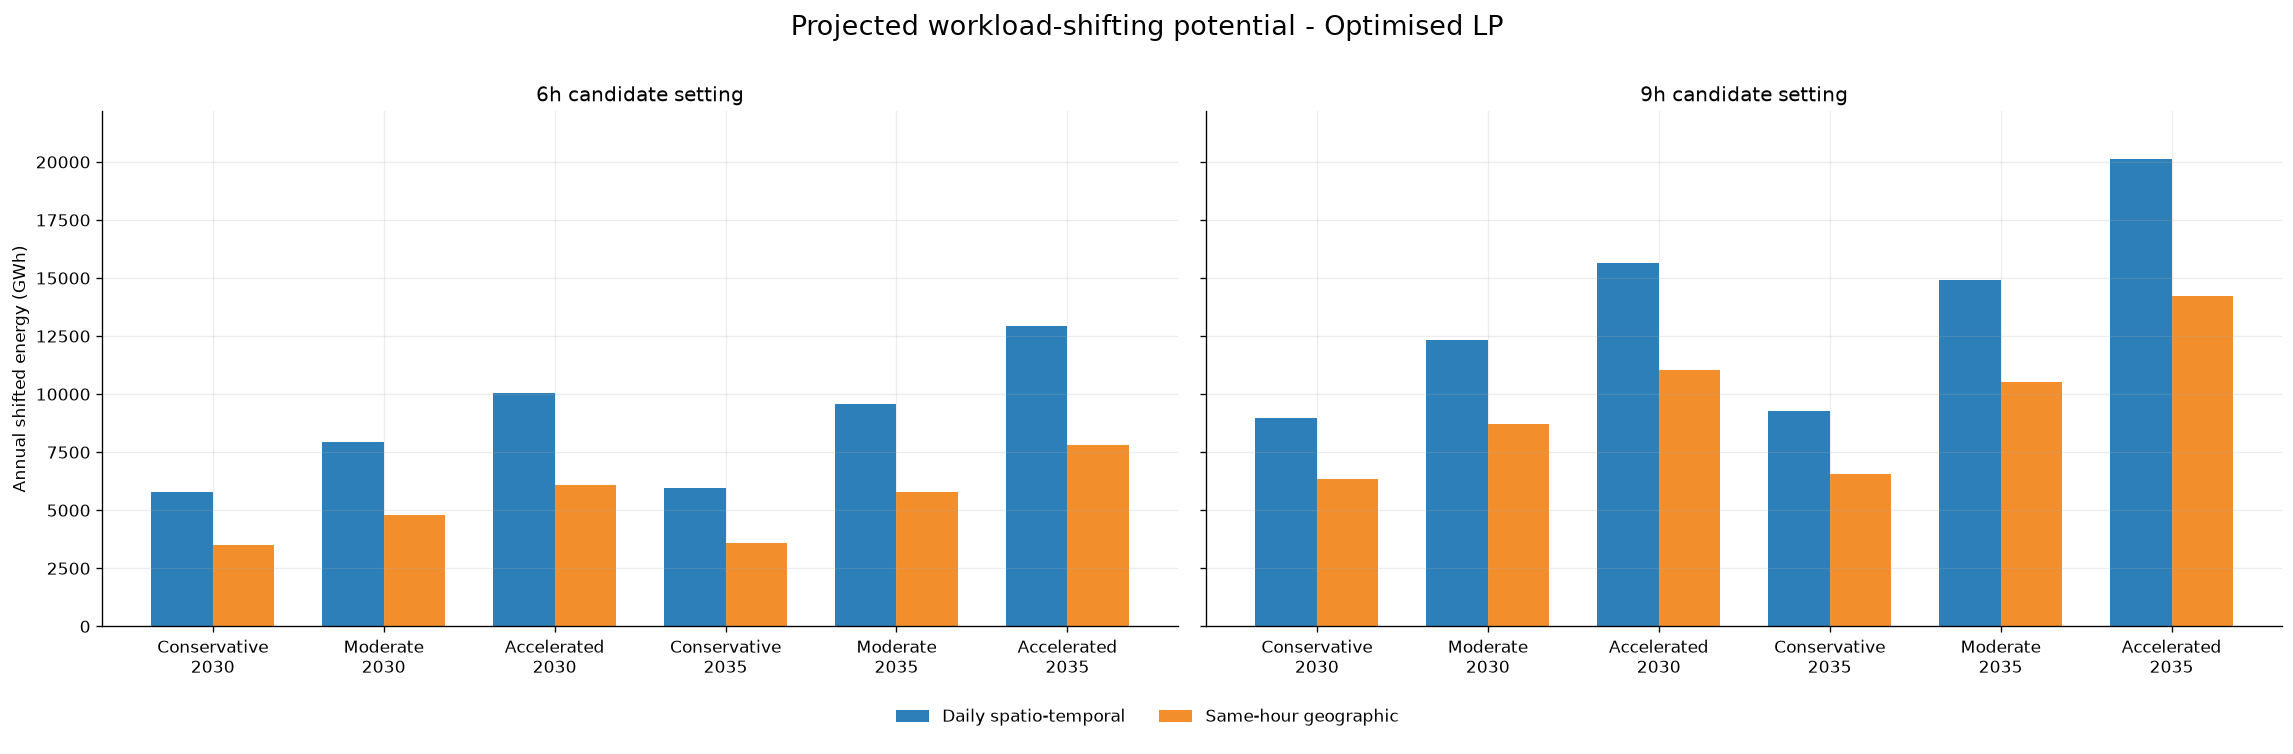

In [9]:
plot_data = reference_summary.loc[reference_summary["allocation_method"].eq("optimised_lp")].copy()

fig = plot_shifted_energy(
    plot_data, hours=CANDIDATE_HOURS, labels=ENDPOINT_LABELS, method_label=METHOD_LABELS["optimised_lp"],
    modes=MODE_ORDER, mode_labels=MODE_LABELS, colours=MODE_COLOURS, upper=shifted_energy_upper,
)

save_figure(fig, METHOD_OUTPUT_DIRS['optimised_lp'], "01b_projected_shifted_energy_by_endpoint")

## 2 - Utilisation sensitivity

Select the 2035 cases at 25% flexibility and calculate a common energy scale across both methods, shifting modes and candidate-hour settings. Define a plotting function for the utilisation response, with a dashed line at the 85% reference.


In [10]:
utilisation_energy_upper = positive_limit(summary.loc[summary["target_year"].eq(2035) & summary["flexibility_scenario_id"].eq("flex_25"), "shifted_gwh_median"], 1.10)

def plot_utilisation_sensitivity(data, *, hours, method_label, modes, mode_labels, scenarios, scenario_labels, colours, upper):
    fig, axes = plt.subplots(len(hours), len(modes), figsize=(14, 10.5), sharey=True, squeeze=False, layout="constrained")
    fig.get_layout_engine().set(hspace=0.08)
    for row, candidate_hours in enumerate(hours):
        for col, mode in enumerate(modes):
            ax = axes[row, col]
            panel = data.loc[data["candidate_hours"].eq(candidate_hours) & data["shift_mode"].eq(mode)]
            for scenario in scenarios:
                line = panel.loc[panel["demand_scenario_id"].eq(scenario)]
                ax.plot(line["base_utilisation"] * 100, line["shifted_gwh_median"], marker="o", color=colours[scenario], label=scenario_labels[scenario])
            ax.axvline(85, color="#666666", linewidth=1, linestyle="--")
            ax.set_title(f"{mode_labels[mode]} ({candidate_hours} candidate hours)")
            ax.set_xlabel("Nominal utilisation (%)")
            ax.set_ylim(0, upper)
        axes[row, 0].set_ylabel("Annual shifted energy (GWh)")
    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="outside lower center", ncol=3, frameon=False, title="IEA endpoint", borderpad=1.4)
    fig.suptitle(f"2035 utilisation sensitivity at 25% flexibility - {method_label}\n")
    return fig

### 2a - Utilisation sensitivity: Greedy

Plot Greedy's response to 80%, 85% and 90% utilisation at fixed 25% flexibility for the three 2035 demand scenarios. Show both shifting modes and candidate-hour settings on comparable scales.


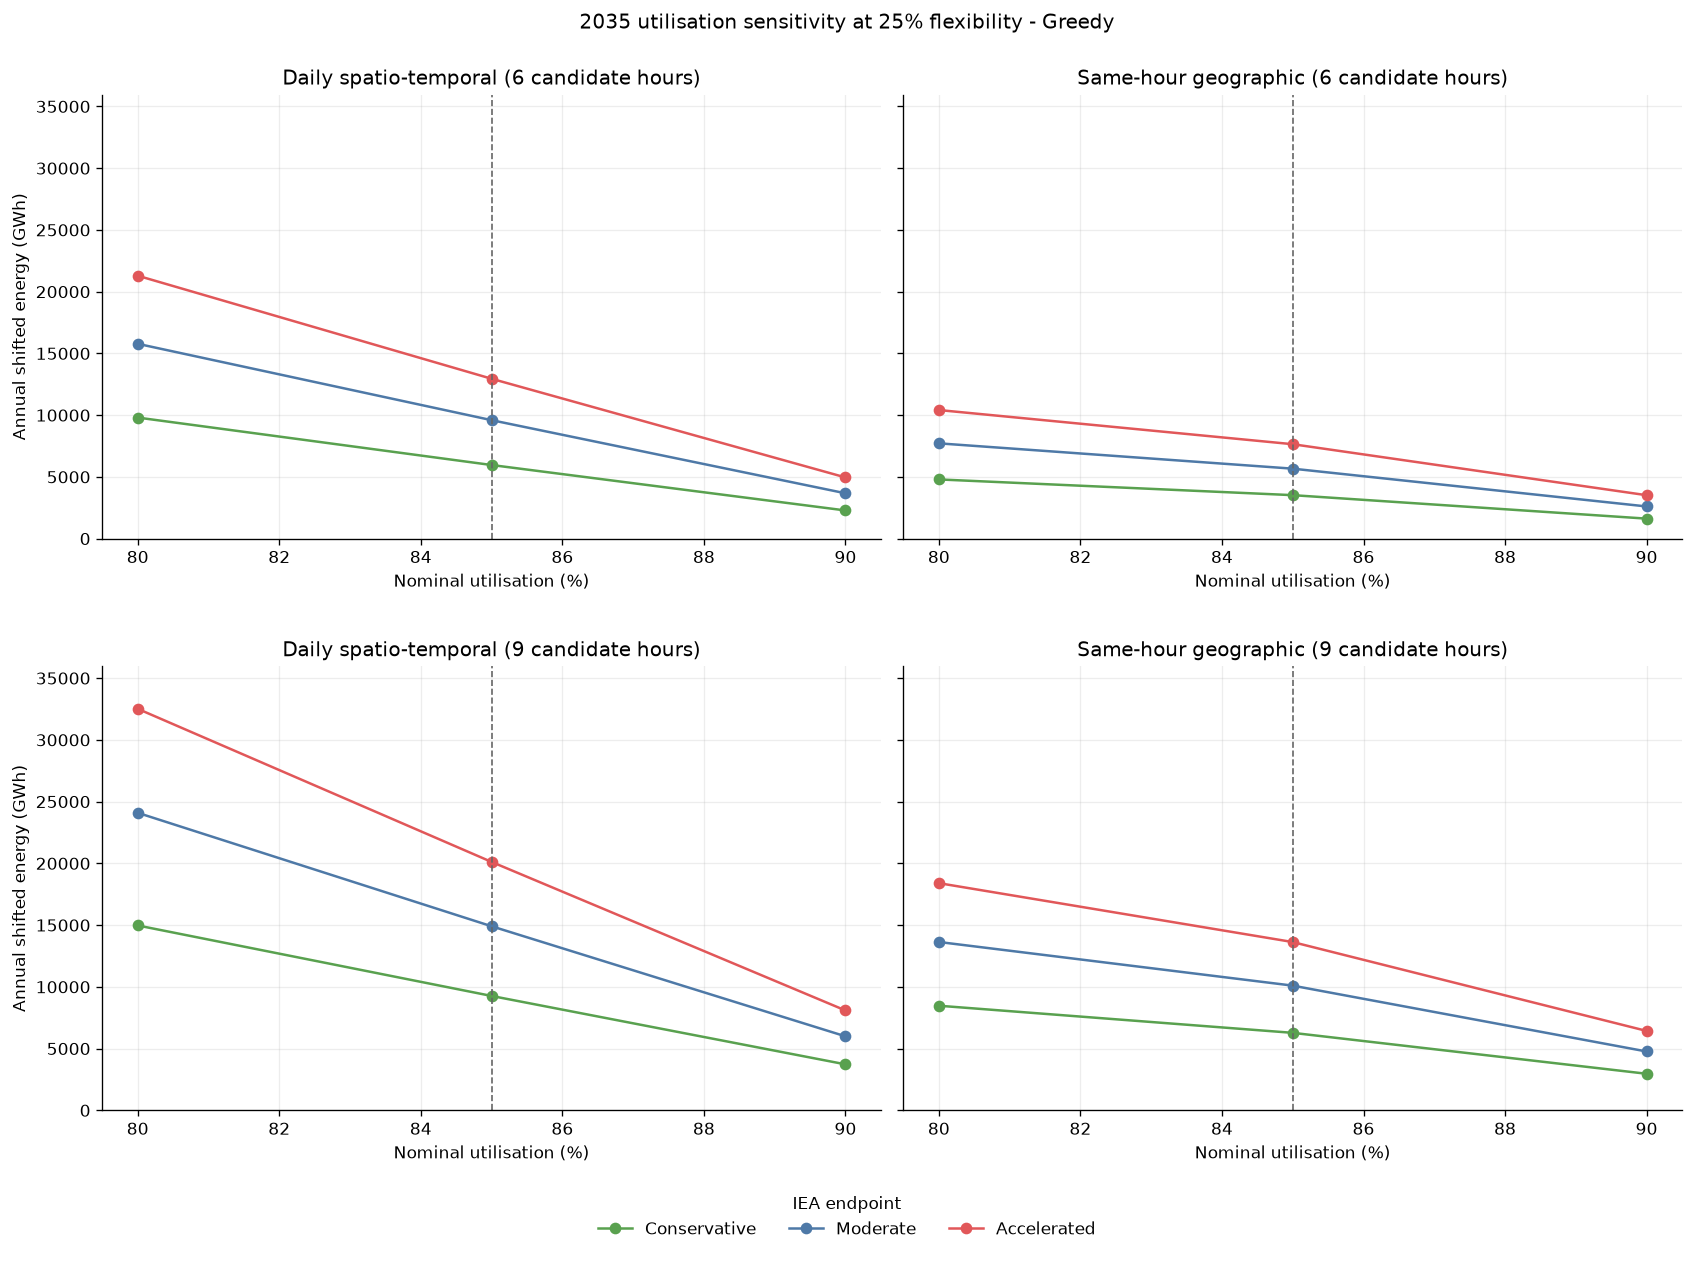

In [11]:
plot_data = summary.loc[
    summary["allocation_method"].eq("greedy") & summary["target_year"].eq(2035)
    & summary["flexibility_scenario_id"].eq("flex_25")
].sort_values(["candidate_hours", "shift_mode", "demand_scenario_id", "base_utilisation"])

fig = plot_utilisation_sensitivity(
    plot_data, hours=CANDIDATE_HOURS, method_label=METHOD_LABELS["greedy"],
    modes=MODE_ORDER, mode_labels=MODE_LABELS, scenarios=SCENARIO_ORDER,
    scenario_labels=SCENARIO_LABELS, colours=SCENARIO_COLOURS, upper=utilisation_energy_upper,
)

save_figure(fig, METHOD_OUTPUT_DIRS['greedy'], "02a_projected_utilisation_sensitivity")

### 2b - Utilisation sensitivity: Optimised LP

Plot LP's response to the same utilisation assumptions and 2035 demand scenarios. Use the same axis limits and reference marker as the Greedy comparison.


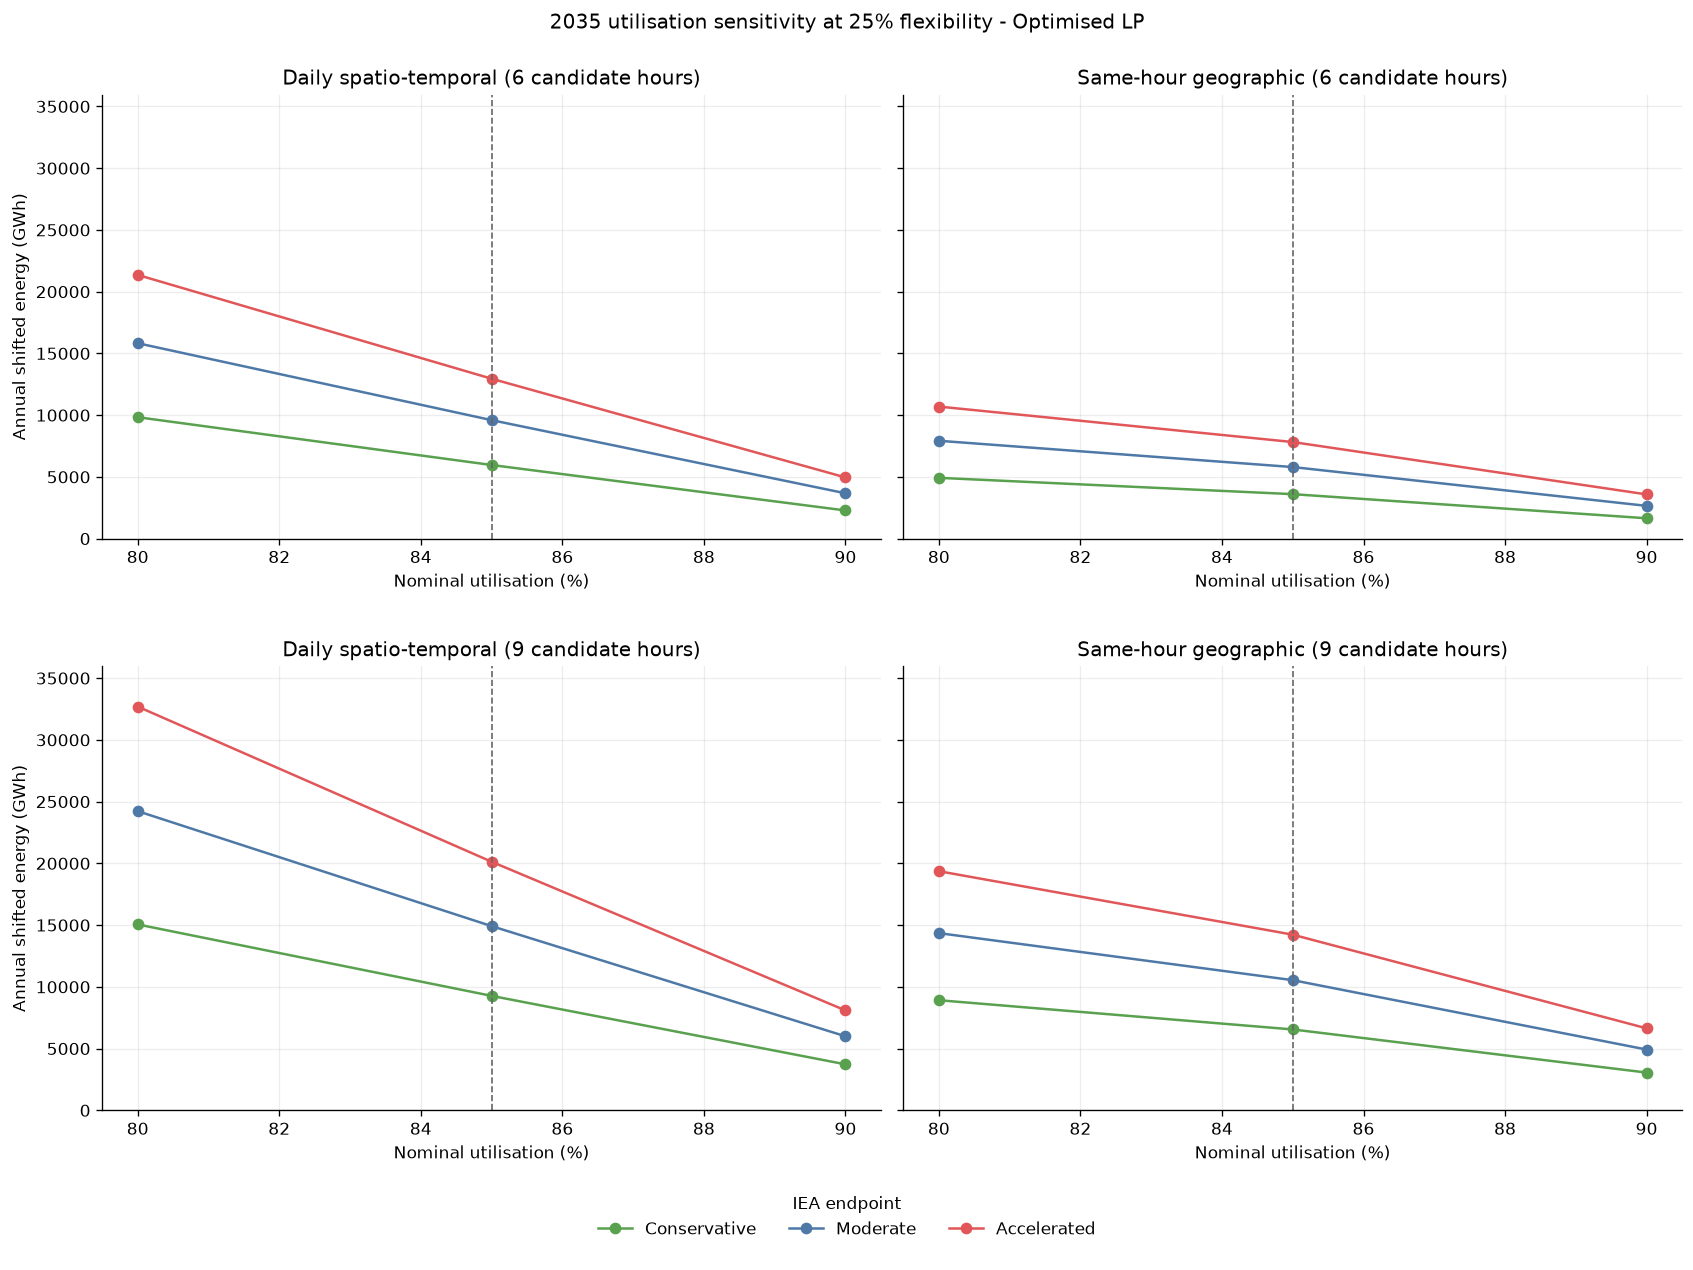

In [12]:
plot_data = summary.loc[
    summary["allocation_method"].eq("optimised_lp") & summary["target_year"].eq(2035)
    & summary["flexibility_scenario_id"].eq("flex_25")
].sort_values(["candidate_hours", "shift_mode", "demand_scenario_id", "base_utilisation"])

fig = plot_utilisation_sensitivity(
    plot_data, hours=CANDIDATE_HOURS, method_label=METHOD_LABELS["optimised_lp"],
    modes=MODE_ORDER, mode_labels=MODE_LABELS, scenarios=SCENARIO_ORDER,
    scenario_labels=SCENARIO_LABELS, colours=SCENARIO_COLOURS, upper=utilisation_energy_upper,
)

save_figure(fig, METHOD_OUTPUT_DIRS['optimised_lp'], "02b_projected_utilisation_sensitivity")

## 3 - Full workload grid

Select moderate 2035 daily shifting and calculate a shared colour scale across all nine workload combinations, both methods and both candidate-hour settings. Define a heatmap function that labels each cell with median annual shifted energy.


In [13]:
moderate_daily = summary.loc[
    summary["target_year"].eq(2035) & summary["demand_scenario_id"].eq("moderate")
    & summary["shift_mode"].eq("daily_spatiotemporal")
]
workload_matrix_upper = positive_limit(moderate_daily["shifted_gwh_median"])

def plot_nine_case_heatmap(matrices, *, hours, method_label, upper):
    """Draw the supplied workload-case matrices with a shared scale and numeric labels."""
    fig, axes = plt.subplots(1, len(hours), figsize=(15.5, 6.4), layout="constrained")
    for ax, candidate_hours in zip(np.atleast_1d(axes), hours):
        matrix = matrices[candidate_hours]
        im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=upper)
        ax.set_xticks(range(len(matrix.columns)), [f"{value:.0%}" for value in matrix.columns])
        ax.set_yticks(range(len(matrix.index)), [f"{value:.0%}" for value in matrix.index])
        ax.set_xlabel("Flexible workload share")
        ax.set_ylabel("Nominal utilisation")
        ax.set_title(f"{candidate_hours}h candidate setting")
        ax.grid(False)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix.iloc[i, j]
                ax.text(j, i, f"{value:,.0f}", ha="center", va="center", color="white" if value > upper * 0.55 else "black")
    fig.colorbar(im, ax=list(np.atleast_1d(axes)), label="Annual shifted energy (GWh; median across weather runs)", shrink=0.85)
    fig.suptitle(f"Moderate 2035 daily nine-case sensitivity - {method_label}\n", fontsize=14)
    return fig

### 3a - Full nine-case sensitivity: Greedy

Plot all combinations of 80%/85%/90% utilisation and 20%/25%/30% flexibility for Greedy's moderate 2035 daily result. Each cell shows median annual energy across weather runs, using the common colour scale for both candidate-hour settings.


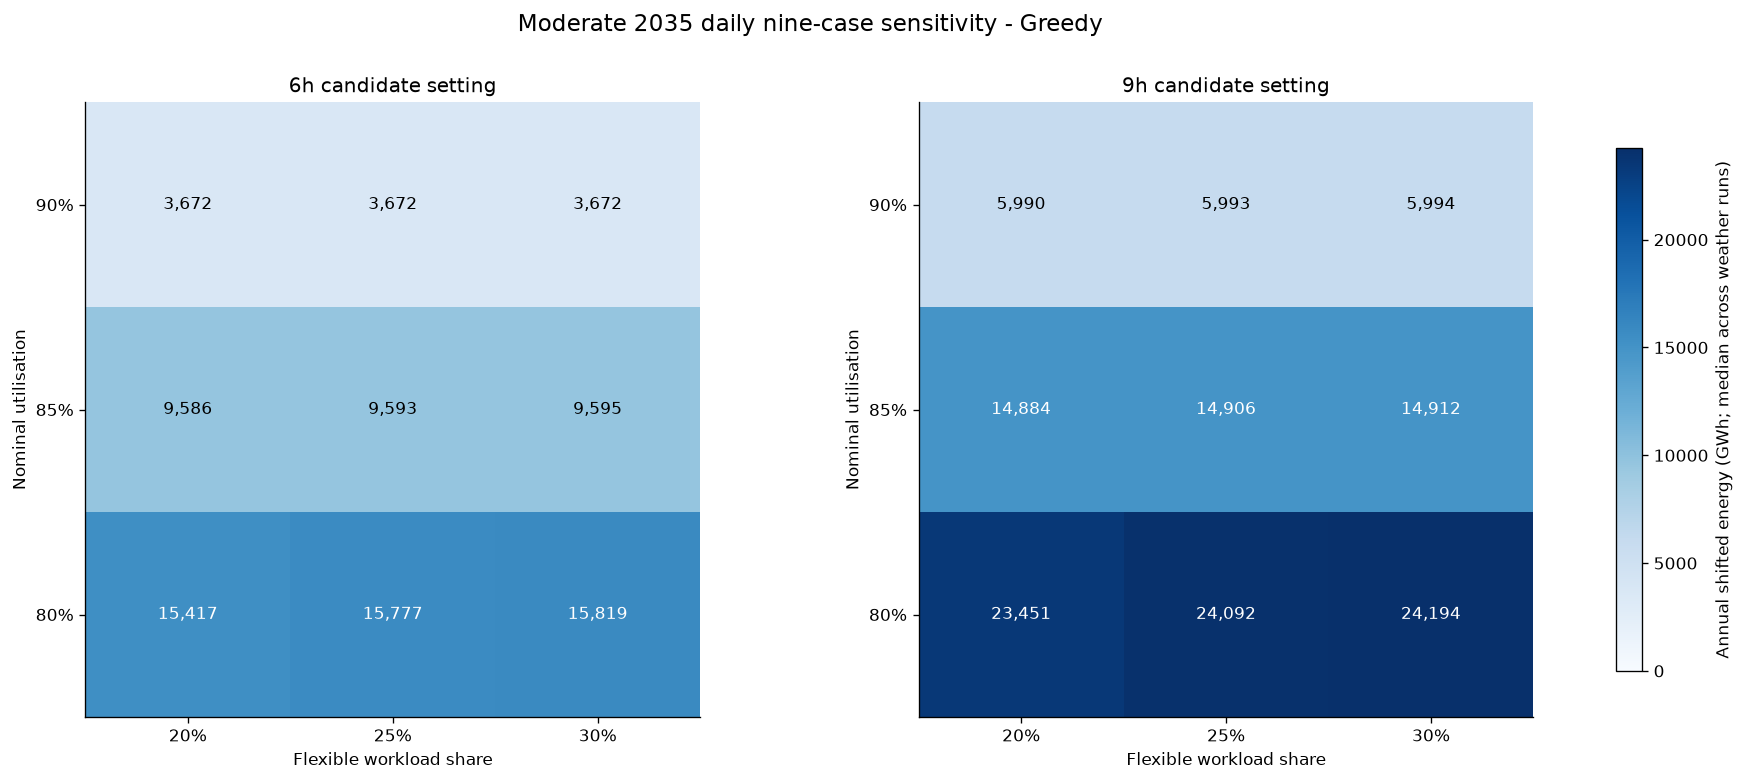

In [14]:
plot_data = moderate_daily.loc[moderate_daily["allocation_method"].eq("greedy")]

matrices = {hours: plot_data.loc[plot_data["candidate_hours"].eq(hours)].pivot(
    index="base_utilisation", columns="flexible_workload_share", values="shifted_gwh_median",
).sort_index(ascending=False).sort_index(axis=1) for hours in CANDIDATE_HOURS}

fig = plot_nine_case_heatmap(
    matrices, hours=CANDIDATE_HOURS, method_label=METHOD_LABELS["greedy"], upper=workload_matrix_upper,
)

save_figure(fig, METHOD_OUTPUT_DIRS['greedy'], "03a_projected_workload_sensitivity_matrix")

### 3b - Full nine-case sensitivity: Optimised LP

Plot the same nine workload combinations for LP's moderate 2035 daily result. Retain the colour scale used for Greedy so the method and candidate-hour comparisons remain consistent.


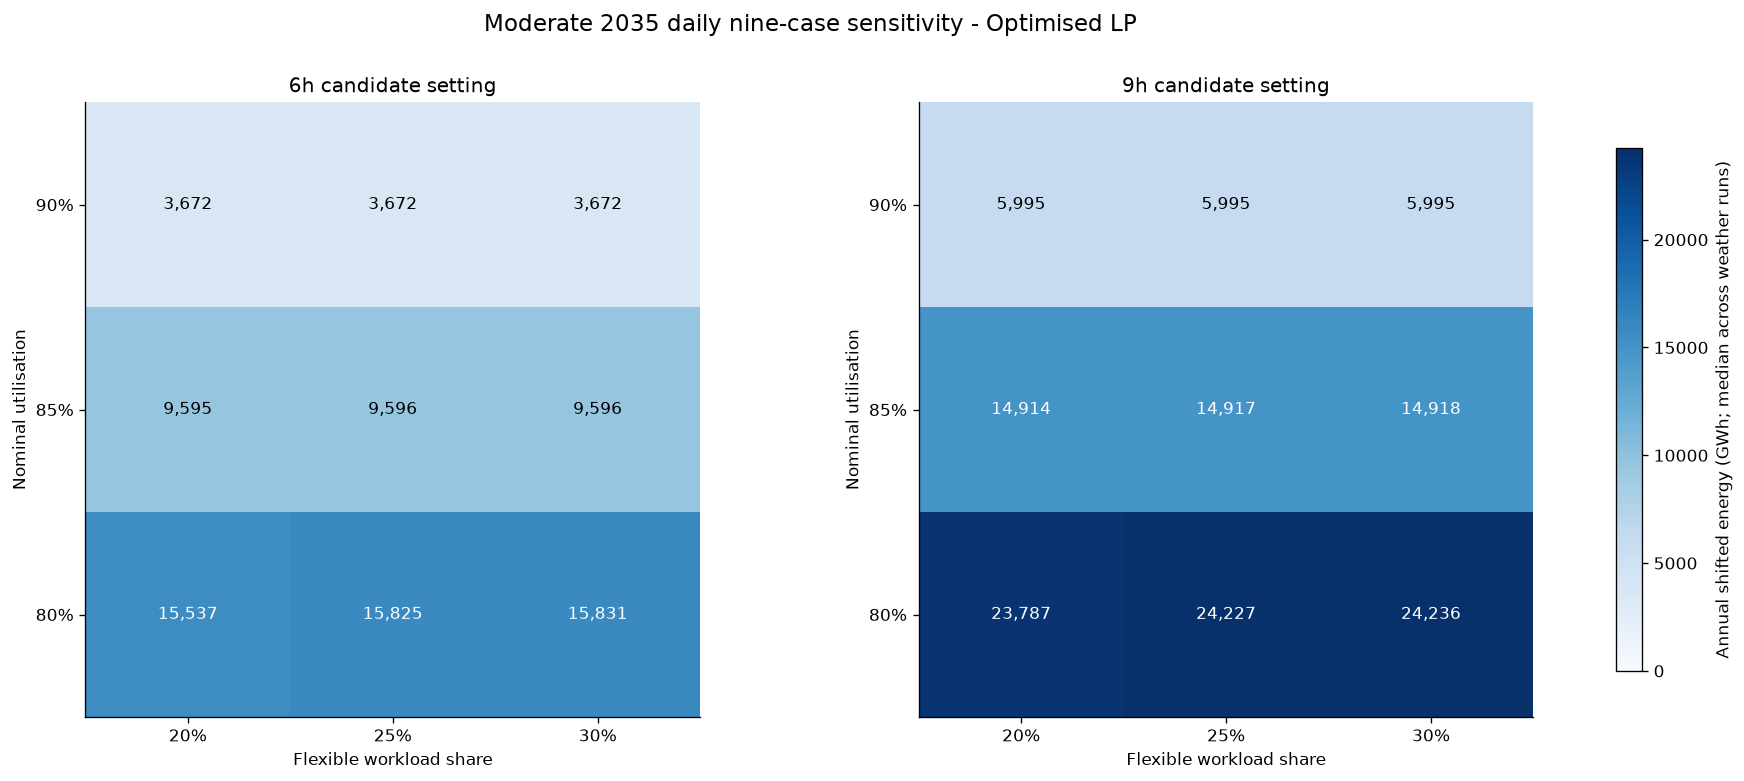

In [15]:
plot_data = moderate_daily.loc[moderate_daily["allocation_method"].eq("optimised_lp")]

matrices = {hours: plot_data.loc[plot_data["candidate_hours"].eq(hours)].pivot(
    index="base_utilisation", columns="flexible_workload_share", values="shifted_gwh_median",
).sort_index(ascending=False).sort_index(axis=1) for hours in CANDIDATE_HOURS}

fig = plot_nine_case_heatmap(
    matrices, hours=CANDIDATE_HOURS, method_label=METHOD_LABELS["optimised_lp"], upper=workload_matrix_upper,
)

save_figure(fig, METHOD_OUTPUT_DIRS['optimised_lp'], "03b_projected_workload_sensitivity_matrix")

## 4 - Directed regional flows

Select moderate 2035 daily shifting at 85% utilisation and 25% flexibility, then calculate a common colour scale for both methods and candidate-hour settings. Define a heatmap with sending regions in rows and receiving regions in columns. Each cell contains a pairwise median across weather runs, so the cells do not sum to the network median.


In [16]:
reference_region = region.loc[
    region["target_year"].eq(2035) & region["demand_scenario_id"].eq("moderate")
    & region["utilisation_scenario_id"].eq("util_85") & region["flexibility_scenario_id"].eq("flex_25")
    & region["shift_mode"].eq("daily_spatiotemporal")
].copy()

regional_flow_upper = positive_limit(reference_region["shifted_gwh_median"])

def plot_region_pair_heatmap(matrices, *, hours, method_label, upper):
    fig, axes = plt.subplots(1, len(hours), figsize=(18, 7.3), layout="constrained")
    region_labels = {"Asia Pacific": "Asia\nPacific", "Latin America": "Latin\nAmerica", "Middle East and Africa": "Middle East\nand Africa", "North America": "North\nAmerica"}
    for ax, candidate_hours in zip(np.atleast_1d(axes), hours):
        matrix = matrices[candidate_hours]
        im = ax.imshow(matrix, cmap="YlGnBu", vmin=0, vmax=upper)
        ax.set_xticks(range(len(matrix.columns)), [region_labels.get(label, label) for label in matrix.columns], rotation=0, ha="center")
        ax.set_yticks(range(len(matrix.index)), [region_labels.get(label, label) for label in matrix.index])
        ax.set_xlabel("Receiver world region", labelpad=12)
        ax.set_ylabel("Sender world region", labelpad=12)
        ax.set_title(f"{candidate_hours}h candidate setting", pad=15)
        ax.grid(False)
    fig.colorbar(im, ax=list(np.atleast_1d(axes)), label="Annual shifted energy (GWh)", shrink=0.85)
    fig.suptitle(f"Moderate 2035 daily flow pattern - {method_label}\n", fontsize=15)
    return fig

### 4a - Directed-region flows: Greedy

Plot Greedy's directed world-region flows for the moderate 2035 daily reference case. Diagonal cells represent transfers between different query locations within the same world region.


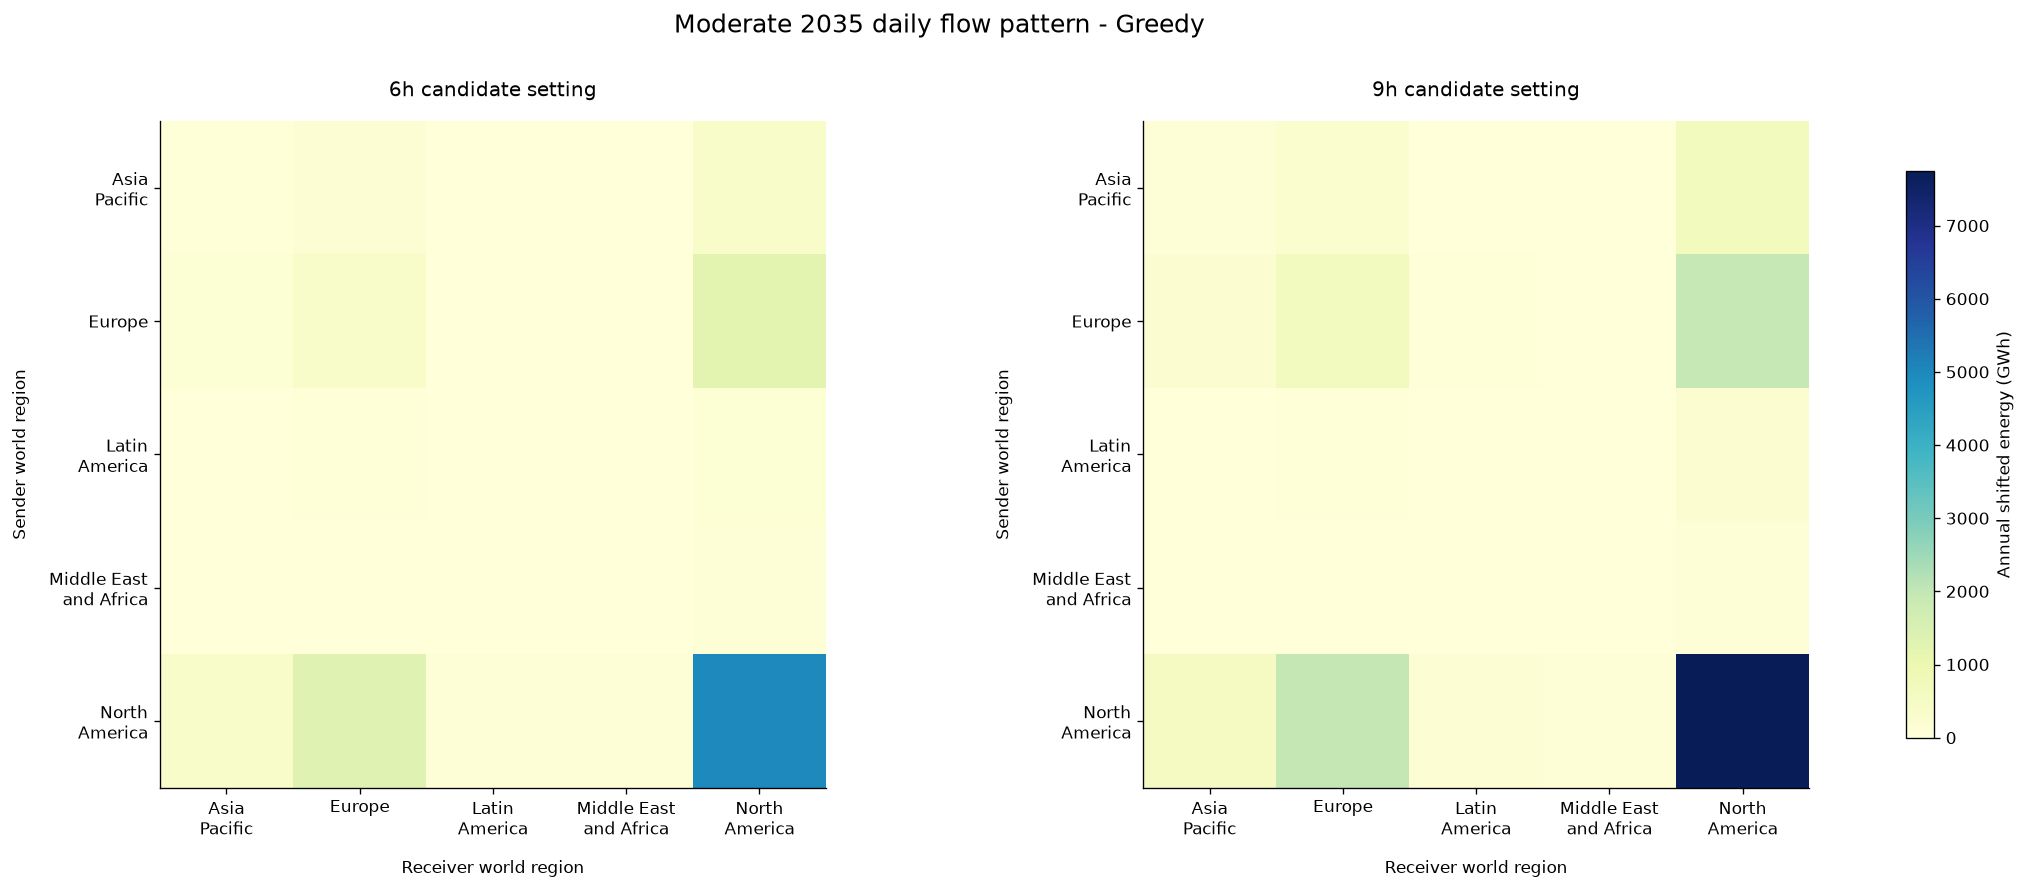

In [17]:
plot_data = reference_region.loc[reference_region["allocation_method"].eq("greedy")]

matrices = {hours: plot_data.loc[plot_data["candidate_hours"].eq(hours)].pivot(
    index="sender_world_region", columns="receiver_world_region", values="shifted_gwh_median",
).sort_index().sort_index(axis=1) for hours in CANDIDATE_HOURS}

fig = plot_region_pair_heatmap(
    matrices, hours=CANDIDATE_HOURS, method_label=METHOD_LABELS["greedy"], upper=regional_flow_upper,
)

save_figure(fig, METHOD_OUTPUT_DIRS['greedy'], "04a_projected_directed_region_flows")

### 4b - Directed-region flows: Optimised LP

Plot LP's directed world-region flows for the same case and on the same colour scale as Greedy. The regional pattern describes the selected solution and can vary between equally optimal LP allocations.


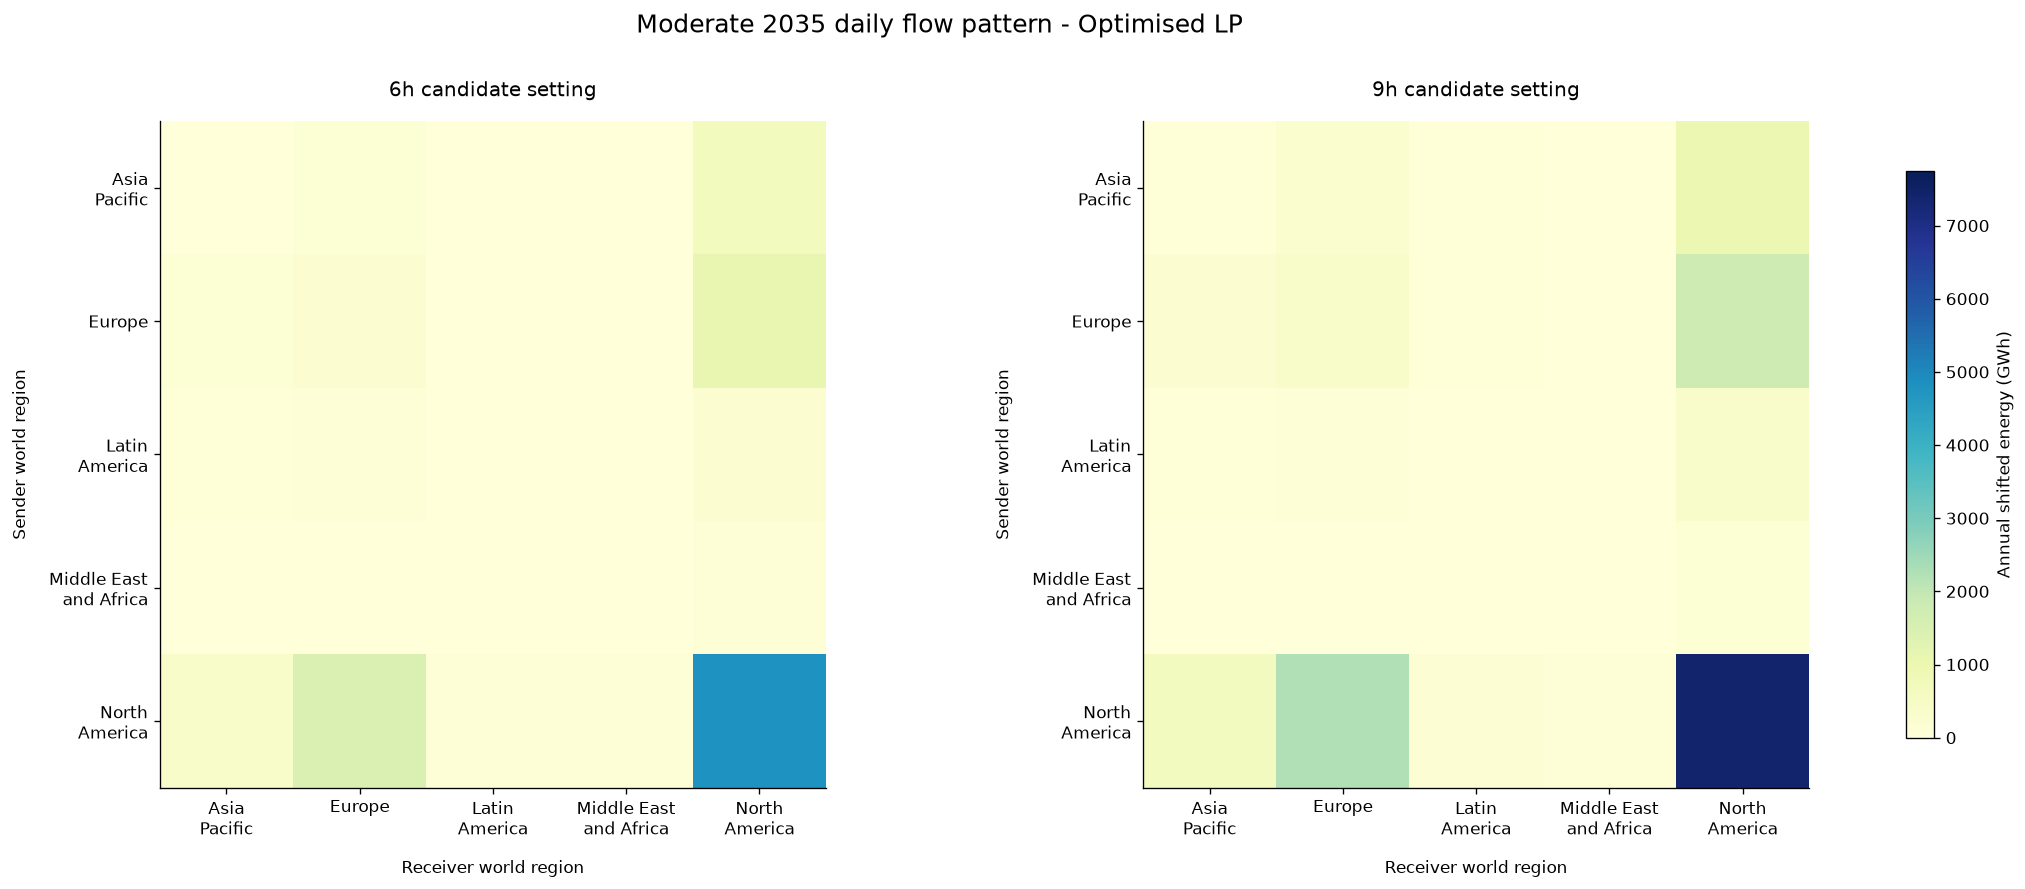

In [18]:
plot_data = reference_region.loc[reference_region["allocation_method"].eq("optimised_lp")]

matrices = {hours: plot_data.loc[plot_data["candidate_hours"].eq(hours)].pivot(
    index="sender_world_region", columns="receiver_world_region", values="shifted_gwh_median",
).sort_index().sort_index(axis=1) for hours in CANDIDATE_HOURS}

fig = plot_region_pair_heatmap(
    matrices, hours=CANDIDATE_HOURS, method_label=METHOD_LABELS["optimised_lp"], upper=regional_flow_upper,
)

save_figure(fig, METHOD_OUTPUT_DIRS['optimised_lp'], "04b_projected_directed_region_flows")